# Análisis Exploratorio de Datos (EDA) y Visualización

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from folium.plugins import HeatMap

# Configuración visual
sns.set_theme(style="whitegrid")

# Cargar los datos limpios (subimos un nivel en la ruta porque estamos en /notebooks)
df = pd.read_csv('../data/processed/uber_lyft_cleaned.csv')

print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Datos cargados: 635242 filas y 19 columnas


,distance,cab_type,destination,source,price,surge_multiplier,product_id,name,datetime,date_hour,hour,day_of_week,is_weekend,temp,clouds,pressure,rain,humidity,wind
0,0.44,Lyft,North Station,Haymarket Square,5.0,1.0,lyft_line,Shared,2018-12-16 09:30:07.890,2018-12-16 09:00:00,9,6,1,38.460,0.290000,1022.25,0.000,0.760000,7.68
1,0.44,Lyft,North Station,Haymarket Square,11.0,1.0,lyft_premier,Lux,2018-11-27 02:00:23.677,2018-11-27 02:00:00,2,1,0,44.065,0.995000,1002.88,0.106,0.895000,12.63
2,0.44,Lyft,North Station,Haymarket Square,26.0,1.0,lyft_luxsuv,Lux Black XL,2018-11-30 04:53:02.749,2018-11-30 04:00:00,4,4,0,35.080,0.000000,1013.71,0.000,0.700000,5.25
3,0.44,Lyft,North Station,Haymarket Square,9.0,1.0,lyft_plus,Lyft XL,2018-11-29 03:49:20.223,2018-11-29 03:00:00,3,3,0,37.680,0.433333,998.42,0.000,0.706667,11.16
4,0.44,Lyft,North Station,Haymarket Square,16.5,1.0,lyft_lux,Lux Black,2018-12-17 18:25:12.138,2018-12-17 18:00:00,18,0,0,40.780,0.930000,1000.15,0.000,0.790000,7.55


## Análisis de Precios (Uber vs Lyft)
¿Quién es más caro en promedio?

C:\Users\anton\AppData\Local\Temp\ipykernel_23364\1711539936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cab_type', y='price', palette='Set2')


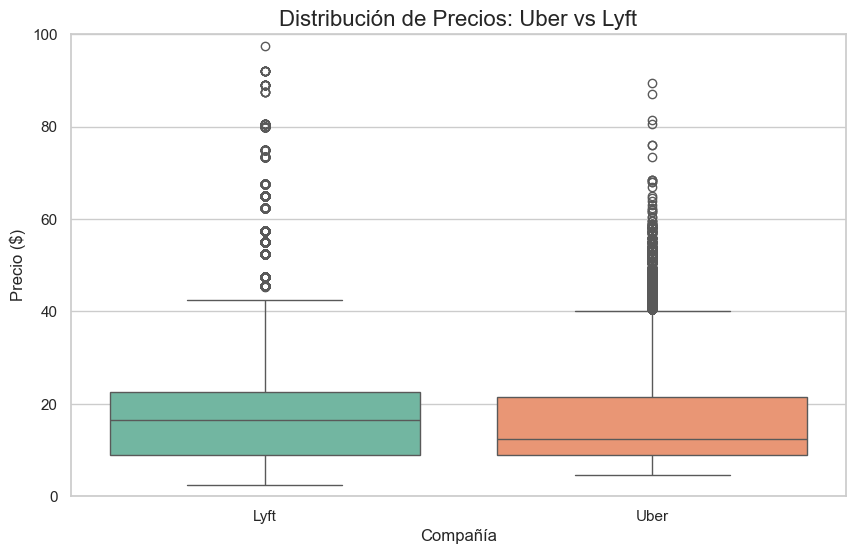

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='cab_type', y='price', palette='Set2')
plt.title('Distribución de Precios: Uber vs Lyft', fontsize=16)
plt.xlabel('Compañía')
plt.ylabel('Precio ($)')
# Limitamos el eje Y a 100 para visualizar mejor la caja (ignorando super outliers)
plt.ylim(0, 100) 
plt.show()

## Celda 3: Matriz de Correlación (Impacto del clima y distancia)
Insight: Demostramos estadísticamente qué variables afectan el precio.

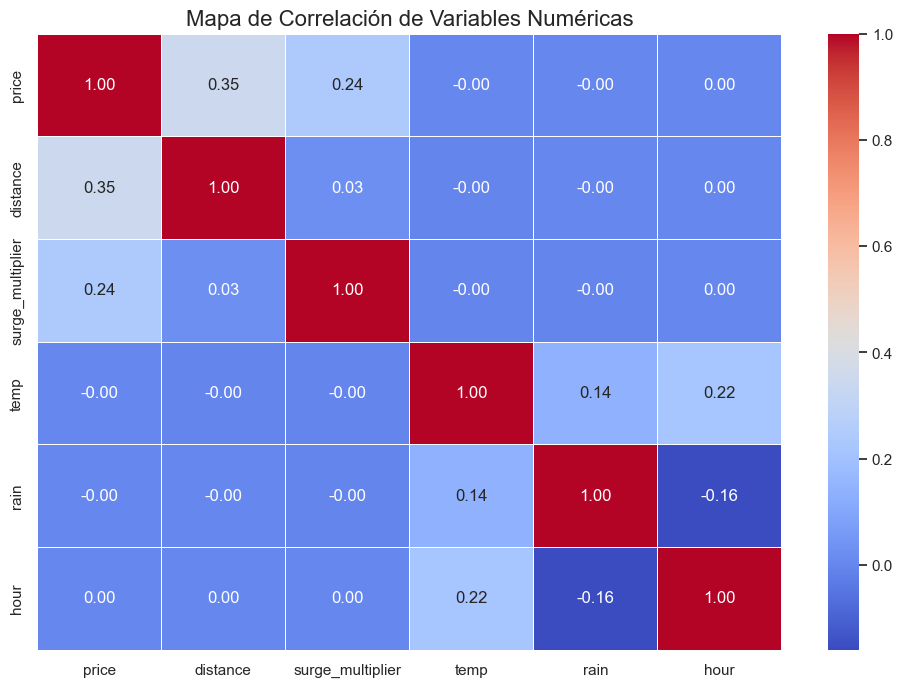

In [4]:
plt.figure(figsize=(12, 8))
# Seleccionamos solo variables numéricas relevantes
cols_numericas = ['price', 'distance', 'surge_multiplier', 'temp', 'rain', 'hour']
matriz_corr = df[cols_numericas].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas', fontsize=16)
plt.show()

## Visualización Interactiva con Plotly (Distancia vs Precio)
Tomamos una muestra de 2000 viajes para que el navegador no colapse al renderizar el gráfico interactivo.

In [ ]:
# Muestreo aleatorio para visualización rápida
df_sample = df.sample(2000, random_state=42)

fig = px.scatter(df_sample, x='distance', y='price', color='name', hover_data=['cab_type'],
                 title='Relación Distancia vs Precio (Interactivo por Tipo de Servicio)',
                 labels={'distance': 'Distancia (millas)', 'price': 'Precio ($)', 'name': 'Servicio'})
fig.show()

## El "Valor Agregado" - Mapa de Calor Geográfico (Folium)
El dataset solo tiene nombres de barrios en Boston, no coordenadas. ¡Como buenos ingenieros, mapeamos las coordenadas manualmente para crear un mapa de impacto visual increíble!

In [8]:
# Coordenadas aproximadas de los barrios de Boston
boston_coords = {
    'Back Bay': [42.3503, -71.0810], 'Beacon Hill': [42.3588, -71.0707],
    'Boston University': [42.3505, -71.1054], 'Fenway': [42.3429, -71.1003],
    'Financial District': [42.3559, -71.0550], 'Haymarket Square': [42.3628, -71.0585],
    'North End': [42.3647, -71.0542], 'North Station': [42.3661, -71.0631],
    'Northeastern University': [42.3398, -71.0892], 'South Station': [42.3519, -71.0552],
    'Theatre District': [42.3519, -71.0643], 'West End': [42.3624, -71.0637]
}

# Contar cuántos viajes se originaron en cada ubicación
demand_by_location = df['source'].value_counts().reset_index()
demand_by_location.columns = ['location', 'count']

# Añadir latitud y longitud al conteo
demand_by_location['lat'] = demand_by_location['location'].map(lambda x: boston_coords[x][0])
demand_by_location['lon'] = demand_by_location['location'].map(lambda x: boston_coords[x][1])

# Crear mapa centrado en Boston
mapa_boston = folium.Map(location=[42.3550, -71.0650], zoom_start=13)

# Preparar datos para el mapa de calor [lat, lon, peso]
heat_data = [[row['lat'], row['lon'], row['count']] for index, row in demand_by_location.iterrows()]

# Añadir mapa de calor
HeatMap(heat_data, radius=25, blur=15).add_to(mapa_boston)

# Mostrar mapa interactivo
mapa_boston